In [1]:
import firedrake
import numpy as np
import pickle as pkl
from numpy import pi as π
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import firedrake
from firedrake import Constant, inner, sqrt, tr, grad, div, as_vector, exp,sym, as_vector, dx, ds, Mesh, Function, project, TransferManager
import meshpy, meshpy.geometry, meshpy.triangle
import irksome
from irksome import Dt
from scipy.signal import detrend
import copy
import matplotlib
import irksome
from irksome import Dt
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import pickle as pkl
import tqdm
import emcee
import corner
import itertools
import xarray
import dtscalibration
import glob
from rasterio.plot import show
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import os
import sys
from pyproj import Transformer
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from scripts.AH_temp_funcs import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import shapefile as sf

import rasterio
from rasterio.enums import Resampling
from rasterio.mask import mask

from firedrake.checkpointing import DumbCheckpoint

from firedrake import *

%matplotlib widget

# Load the flow

In [90]:
upscale_factor_fine = 1/10
src_bed_fine = rasterio.open("Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_bed.tif")
src_surf_fine = rasterio.open("Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_surf.tif")
src_bed = src_bed_fine
src_surf = src_surf_fine

bed_DEM = src_bed.read(1,
                        out_shape=(
                            src_bed.count,
                            int(src_bed.height * upscale_factor_fine),
                            int(src_bed.width * upscale_factor_fine)
                        ),
                        resampling=Resampling.bilinear
                    )

# scale image transform
src_bed_transform = src_bed.transform * src_bed.transform.scale(
    (src_bed.width / bed_DEM.shape[-1]),
    (src_bed.height / bed_DEM.shape[-2])
)

surf_DEM = src_surf.read(1,
                        out_shape=(
                            src_surf.count,
                            int(src_surf.height * upscale_factor_fine),
                            int(src_surf.width * upscale_factor_fine)
                        ),
                        resampling=Resampling.bilinear
                    )

# scale image transform
src_surf_transform = src_surf.transform * src_surf.transform.scale(
    (src_surf.width / surf_DEM.shape[-1]),
    (src_surf.height / surf_DEM.shape[-2])
)

### Check if the bed DEMs is higher than the surface DEM (thickness is negative) ###


thickness = surf_DEM - bed_DEM
thickness[thickness > 0] = 0  # if positive, set to 0. This will mask the negative thickness values
zero_offset = copy.deepcopy(thickness)
zero_offset[zero_offset < 0 ] = -1 # this mask will lower the bed a further 1m in the areas where thickness is negative so the model doesn't crash on a zero.
bed_DEM = bed_DEM + thickness + zero_offset # add the negative values to the bed to push it lower to match the surface DEM

height = surf_DEM.shape[0]
width = surf_DEM.shape[1]
cols, rows = np.meshgrid(np.arange(width), np.arange(height))
xs, ys = rasterio.transform.xy(src_surf_transform, rows, cols)
lons= np.array(xs)
lats = np.array(ys)

surf_elevs = surf_DEM.flatten()
bed_elevs = bed_DEM.flatten()

"""
Create a unite fine mesh to interpolate the coarse model results onto.
"""

layers = 5 # number of layers in z direction of the extruded mesh
nx = width - 1
ny = height - 1

Lx = lons.max() # x extent, get this from the DEM
Ly = lats.max() # y extent, get this from the DEM

origin_x = lons.min() # origin (lower left corner) in x, get this from the DEM
origin_y = lats.min() # origin (lower left corner) in y, get this from the DEM

base_mesh = RectangleMesh(nx,ny, Lx, Ly, originX=origin_x, originY=origin_y)

unit_extruded_mesh = ExtrudedMesh(base_mesh, layers=layers)

xi = base_mesh.coordinates.dat.data_ro[:,:2] # Get the mesh coordinates from the base mesh

base_fs = FunctionSpace(base_mesh, "CG", 1)

x,y, = SpatialCoordinate(base_mesh)

# You could set this field any way you like.
## Bed and surface DEM resolution should be nx+1, ny+1 as to match the coordinates of the mesh.

# Now we transfer the bathymetry field into a depth-averaged field.
extruded_element = FiniteElement("R", "interval", 0)
extruded_space = FunctionSpace(unit_extruded_mesh,
                                TensorProductElement(base_fs.ufl_element(),
                                                    extruded_element))


from scipy.interpolate import griddata
## interpolate the DEMs to the mesh coordinates so it is given in the mesh coordinate order
points = np.array([xs,ys]).T # DEM pixel coordinates
xi = base_mesh.coordinates.dat.data_ro[:,:2] # Get the mesh coordinates from the base mesh
surf_interp = griddata(points, surf_DEM.flatten(), xi, method='nearest', fill_value=np.nan, rescale=False)
bed_interp = griddata(points, bed_DEM.flatten(), xi, method='nearest', fill_value=np.nan, rescale=False)

## Extrude the bed and surface
extruded_bed = Function(extruded_space)
extruded_bed.dat.data_wo[:] = bed_interp

extruded_surface = Function(extruded_space)
extruded_surface.dat.data_wo[:] = surf_interp

# Build a new coordinate field by change of coordinates.
x, y, z = SpatialCoordinate(unit_extruded_mesh)
new_coordinates = assemble(
    interpolate(
        as_vector([x, y, (1-z) * extruded_bed + z * extruded_surface]),
        unit_extruded_mesh.coordinates.function_space()
    )
)


# Finally build the mesh you are actually after.
mesh_fine = Mesh(new_coordinates) # Mesh(new_coordinates, tolerance=50)
x_fine, y_fine, z_fine = SpatialCoordinate(mesh_fine)


/opt/firedrake/firedrake/interpolation.py:391: FutureWarning: The use of `interpolate` to perform the numerical interpolation is deprecated.
This feature will be removed very shortly.

Instead, import `interpolate` from the `firedrake.__future__` module to update
the interpolation's behaviour to return the symbolic `ufl.Interpolate` object associated
with this interpolation.

You can then assemble the resulting object to get the interpolated quantity
of interest. For example,

```
from firedrake.__future__ import interpolate
...

assemble(interpolate(expr, V))
```

Alternatively, you can also perform other symbolic operations on the interpolation operator, such as taking
the derivative, and then assemble the resulting form.

  warnings.warn("""The use of `interpolate` to perform the numerical interpolation is deprecated.


In [82]:
pressure_space = firedrake.FunctionSpace(mesh_fine, "CG", 1)
velocity_space = firedrake.VectorFunctionSpace(mesh_fine, "CG", 3)
Y = velocity_space * pressure_space
flow = firedrake.Function(Y)

In [83]:
chk = DumbCheckpoint("Saved_Models/fine_mesh_flow_80.0m_updated_viscosity", mode=FILE_READ)
chk.load(flow, name="fine_mesh_flow")

/opt/firedrake/firedrake/checkpointing.py:103: DeprecationWarning: DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.
  warnings.warn("DumbCheckpoint class will soon be deprecated; use CheckpointFile class instead.",


In [79]:
bed_interp

array([1915.30476457, 1913.12788626, 1907.60749868, ..., 1386.32501762,
       1395.81305923, 1384.7978852 ], shape=(4615,))

In [80]:
points

array([[  506902.38391538, -1350629.2589662 ],
       [  506982.75314615, -1350629.2589662 ],
       [  507063.12237692, -1350629.2589662 ],
       ...,
       [  511885.27622308, -1356284.4702338 ],
       [  511965.64545385, -1356284.4702338 ],
       [  512046.01468462, -1356284.4702338 ]], shape=(4615, 2))

# Load the cross section we want

In [84]:
flowline_surf = pd.read_csv('flowlines/manual_flowlines/csv/ALHIC1902_surface_rema_100m.csv')
flowline_bed = pd.read_csv('flowlines/manual_flowlines/csv/ALHIC1902_bed_merged_100m.csv')
flowline_xs = flowline_surf['E']
flowline_ys = flowline_surf['N']
flowline_bed_elev = flowline_bed['Elev']
flowline_surf_elev = flowline_surf['Elev']
flowline_distance = flowline_surf['Distance']

In [85]:
z_coords = np.linspace(extruded_bed.dat.data_ro[:].min(), extruded_bed.dat.data_ro[:].max(), 500)

In [86]:
vel_prof=[]
u_prof = []
v_prof = []
z_prof = []
vel_prof_coords = []
for n in range(len(flowline_xs)):


    for z_coord in z_coords:
        try:
            velocity = flow.at(flowline_xs[n], flowline_ys[n], z_coord)[0]*spy
            vel_prof.append(velocity)
            u_prof.append(velocity[0])
            v_prof.append(velocity[1])
            z_prof.append(velocity[2])
            distance = np.sqrt((flowline_xs[n]-flowline_xs[0])**2 + (flowline_ys[n]-flowline_ys[0])**2)
            vel_prof_coords.append([distance, z_coord])

        except:
            continue

vel_prof=np.array(vel_prof)
u_prof = np.array(u_prof)
v_prof = np.array(v_prof)
z_prof = np.array(z_prof)
vel_prof_coords = np.array(vel_prof_coords)

In [87]:
dummy_num1 = np.nan

bed_elevs_from_sampling = []
surf_elevs_from_sampling = []

for n,i in enumerate(vel_prof_coords):

    if i[0] != dummy_num1:
        bed_elevs_from_sampling.append(i)
        dummy_num1 = i[0]
        if n != 0:
            surf_elevs_from_sampling.append(surface_elevs_we_want)


    else:
        surface_elevs_we_want = i
        continue
surf_elevs_from_sampling.append(vel_prof_coords[-1])
bed_elevs_from_sampling = np.array(bed_elevs_from_sampling)
surf_elevs_from_sampling = np.array(surf_elevs_from_sampling)

In [88]:
### sample the DEM directly
src_bed_resampled = rasterio.open("Meshes/resampled_meshes/resampled_bed_dem.tif")
coords_flowline = [(x,y) for x,y in zip(flowline_xs, flowline_ys)]
bed_along_flowline_from_tiff = [x for x in src_bed_fine.sample(coords_flowline)]
bed_along_flowline_from_tiff = np.array(bed_along_flowline_from_tiff)

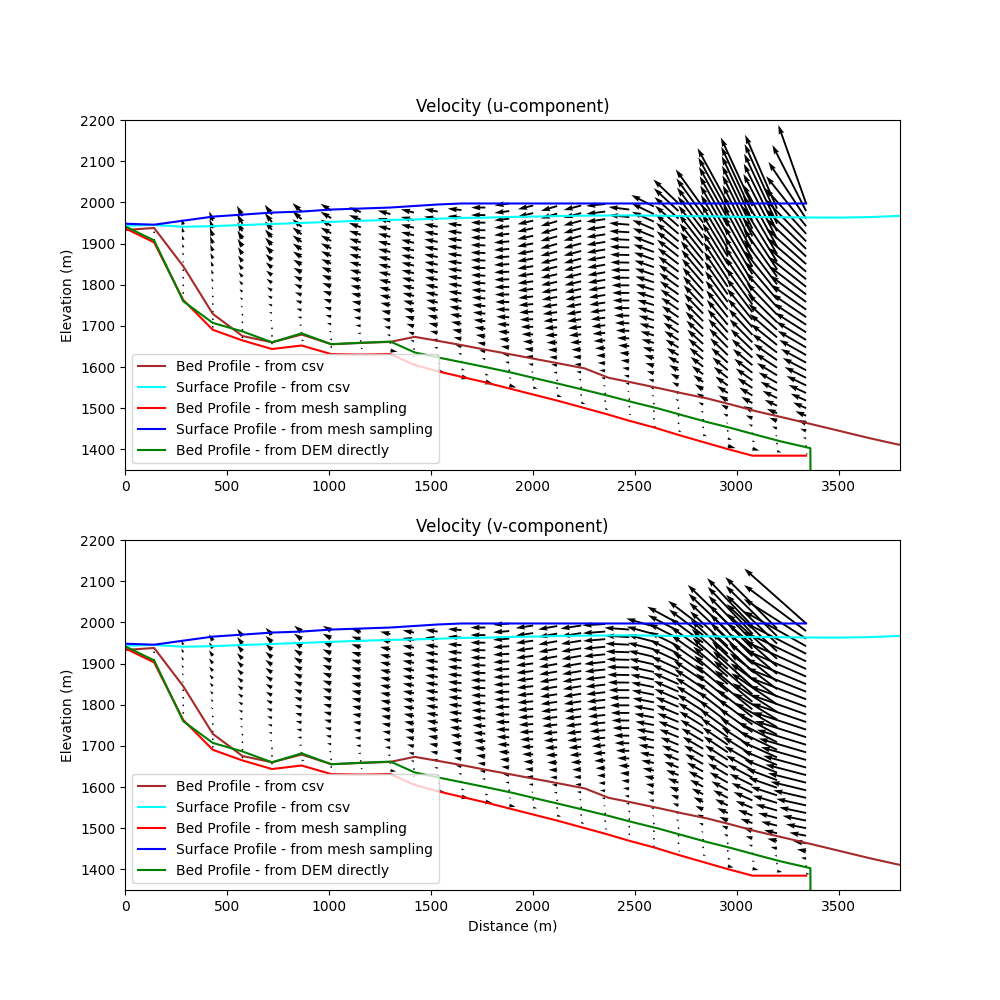

In [89]:
fig,(ax1,ax2) = plt.subplots(2,1,figsize=[10,10])

ax1.quiver(vel_prof_coords[:,0][::15], vel_prof_coords[:,1][::15], u_prof[::15], z_prof[::15],angles='xy', scale_units='xy', scale=None,)
ax2.quiver(vel_prof_coords[:,0][::15], vel_prof_coords[:,1][::15], v_prof[::15], z_prof[::15],angles='xy', scale_units='xy', scale=None,)

ax1.plot(flowline_distance.values,flowline_bed_elev, c='brown', label='Bed Profile - from csv')
ax1.plot(flowline_distance.values,flowline_surf_elev, c='aqua', label='Surface Profile - from csv')

ax2.plot(flowline_distance.values,flowline_bed_elev, c='brown', label='Bed Profile - from csv')
ax2.plot(flowline_distance.values,flowline_surf_elev, c='aqua', label='Surface Profile - from csv')

ax1.plot(bed_elevs_from_sampling[:,0],bed_elevs_from_sampling[:,1], c='red', label='Bed Profile - from mesh sampling')
ax1.plot(surf_elevs_from_sampling[:,0],surf_elevs_from_sampling[:,1], c='blue', label='Surface Profile - from mesh sampling')

ax1.plot(flowline_distance.values,bed_along_flowline_from_tiff, c='green', label='Bed Profile - from DEM directly')

ax2.plot(bed_elevs_from_sampling[:,0],bed_elevs_from_sampling[:,1], c='red', label='Bed Profile - from mesh sampling')
ax2.plot(surf_elevs_from_sampling[:,0],surf_elevs_from_sampling[:,1], c='blue', label='Surface Profile - from mesh sampling')

ax2.plot(flowline_distance.values,bed_along_flowline_from_tiff, c='green', label='Bed Profile - from DEM directly')


ax1.set_ylim([1350,2200])
ax2.set_ylim([1350,2200])

ax1.set_xlim([0,3800])
ax2.set_xlim([0,3800])

ax1.set_ylabel('Elevation (m)')
ax2.set_ylabel('Elevation (m)')

ax2.set_xlabel('Distance (m)')

ax1.set_title('Velocity (u-component)')
ax2.set_title('Velocity (v-component)')

ax1.legend(loc='lower left')
ax2.legend(loc='lower left')

# plt.savefig('Figures/fig4_updated_80m.eps', dpi=300, transparent=True, format='eps')
# plt.savefig('Figures/fig4_updated_80m.png', dpi=300, transparent=False, format='png')


In [50]:
bed_along_flowline_from_tiff
coords_flowline


[(509272.0113, -1353813.228),
 (509383.9188, -1353724.409),
 (509495.8263, -1353635.59),
 (509603.8366, -1353538.678),
 (509711.8469, -1353441.766),
 (509819.8573, -1353344.854),
 (509927.8676, -1353247.942),
 (510035.8779, -1353151.029),
 (510143.8883, -1353054.117),
 (510251.8986, -1352957.205),
 (510357.7773, -1352902.908),
 (510463.6561, -1352848.611),
 (510569.5348, -1352794.315),
 (510675.4136, -1352740.018),
 (510781.2923, -1352685.721),
 (510887.171, -1352631.424),
 (510993.0498, -1352577.127),
 (511098.9285, -1352522.831),
 (511204.8072, -1352468.534),
 (511310.686, -1352414.237),
 (511412.4924, -1352349.194),
 (511514.2989, -1352284.151),
 (511616.1054, -1352219.108),
 (511717.9119, -1352154.065),
 (511819.7184, -1352089.022),
 (511921.5248, -1352023.979),
 (512027.7853, -1351926.626),
 (512134.0458, -1351829.274),
 (512240.3064, -1351731.922),
 (512346.5669, -1351634.569),
 (512359.1715, -1351532.763),
 (512371.7761, -1351430.956),
 (512384.3807, -1351329.15),
 (512396.9853,

# Save the resampled bed dem to check its sampling

In [74]:
upscale_factor_fine = 1/10
src_bed_fine = rasterio.open("Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_bed.tif")
src_surf_fine = rasterio.open("Meshes/crop_aoi/main_boreholes_aoi/main_boreholes_aoi_fix_surf.tif")
src_bed = src_bed_fine
src_surf = src_surf_fine

bed_DEM = src_bed.read(1,
                        out_shape=(
                            src_bed.count,
                            int(src_bed.height * upscale_factor_fine),
                            int(src_bed.width * upscale_factor_fine)
                        ),
                        resampling=Resampling.bilinear
                    )

# scale image transform
src_bed_transform = src_bed.transform * src_bed.transform.scale(
    (src_bed.width / bed_DEM.shape[-1]),
    (src_bed.height / bed_DEM.shape[-2])
)
height = bed_DEM.shape[0]
width = bed_DEM.shape[1]

surf_DEM = src_surf.read(1,
                        out_shape=(
                            src_surf.count,
                            int(src_surf.height * upscale_factor_fine),
                            int(src_surf.width * upscale_factor_fine)
                        ),
                        resampling=Resampling.bilinear
                    )

# scale image transform
src_surf_transform = src_surf.transform * src_surf.transform.scale(
    (src_surf.width / surf_DEM.shape[-1]),
    (src_surf.height / surf_DEM.shape[-2])
)

### Check if the bed DEMs is higher than the surface DEM (thickness is negative) ###


thickness = surf_DEM - bed_DEM
thickness[thickness > 0] = 0  # if positive, set to 0. This will mask the negative thickness values
zero_offset = copy.deepcopy(thickness)
zero_offset[zero_offset < 0 ] = -1 # this mask will lower the bed a further 1m in the areas where thickness is negative so the model doesn't crash on a zero.
bed_DEM = bed_DEM + thickness + zero_offset # add the negative values to the bed to push it lower to match the surface DEM

with rasterio.Env():

    # Write an array as a raster band to a new 8-bit file. For
    # the new file's profile, we start with the profile of the source
    profile = src_bed.profile

    # And then change the band count to 1, set the
    # dtype to uint8, and specify LZW compression.
    profile.update(
        dtype=rasterio.float64,
        count=1,
        compress='lzw',
        width=width,
        height=height,
        transform=src_bed_transform)

    with rasterio.open('Meshes/resampled_meshes/resampled_bed_dem.tif', 'w', **profile) as dst:
        dst.write(bed_DEM.astype(rasterio.float64), 1)

# Debug why the profiles look different

In [48]:
height_true = src_bed_fine.shape[0]
width_true = src_bed_fine.shape[1]
cols_true, rows_true = np.meshgrid(np.arange(width_true), np.arange(height_true))
xs_true, ys_true = rasterio.transform.xy(src_bed_fine.transform, rows_true, cols_true)
lons_true = np.array(xs_true)
lats_true = np.array(ys_true)

bed_elevs_true = src_bed_fine.read(1).flatten()

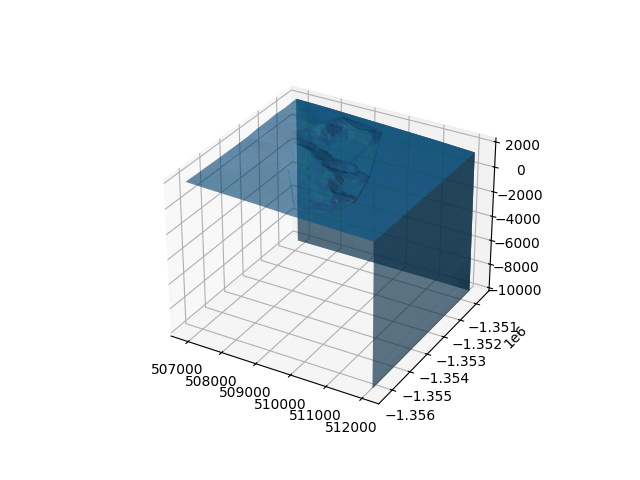

In [52]:
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})

ax.plot_trisurf(lons_true, lats_true, bed_elevs_true)

# ax = plt.figure(figsize=[10,5]).add_subplot(projection='3d')

# ax.scatter(lons_true, lats_true, bed_elevs_true, label="Bed DEM")


In [10]:
import geopandas as gpd

pts = gpd.read_file('/root/AH_temp_paper/flowlines/manual_flowlines/test_flowlines_1902nunatak.shp')

In [26]:
pts

,Id,test_case,geometry
0,0.0,1,"LINESTRING (159.43458 -76.74706, 159.44212 -76..."
1,0.0,2,"LINESTRING (159.38336 -76.74419, 159.36755 -76..."
2,0.0,3,"LINESTRING (159.40679 -76.75369, 159.40207 -76..."
3,0.0,4,"LINESTRING (159.39473 -76.74978, 159.37001 -76..."
4,0.0,5,"LINESTRING (159.41194 -76.76329, 159.39751 -76..."
5,NaN,6,"LINESTRING (159.40225 -76.75254, 159.37147 -76..."
6,NaN,7,"LINESTRING (159.40594 -76.75433, 159.38824 -76..."


In [ ]:
for i in pts.loc()[1]['geometry']:


TypeError: 'LineString' object is not iterable

In [ ]:
pts = pts[['Id', 'UTM_N', 'Value', 'geometry']]
pts.index = range(len(pts))
coords = [(x,y) for x, y in zip(pts.UTM_E, pts.UTM_N)]